# Proyecto Final

### Paso 1 Limpieza de datos:

Aqui lo que haremos es limpiar los datos que no nos sirven, por ejemplo, datos atipicos, valores faltantes o nulos, y datos duplicados. Esto nos facilita para tener resultados mas claros y precisos, sin embargo en este paso basico procederemos a cargar los datos en nuestro entorno junto el dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "darkgrid")

try:
    df = pd.read_csv('train.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo .csv. Por favor, cárgalo en el entorno.")
    
df.head()

Dataset cargado exitosamente.


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')

df.drop_duplicates(inplace=True) ## En este punto eliminamos los datos que estan duplicados


## En esta parte podemos ver que el porcentaje de esta variable lo convertimos a numeros 
if 'host_response_rate' in df.columns:
    
    df['host_response_rate'] = (
        df['host_response_rate']
        .astype(str)
        .str.replace('%', '', regex=False)
    )

    df['host_response_rate'] = pd.to_numeric(
        df['host_response_rate'],
        errors='coerce'
    )

# Esto se cambia ya que esta variable no se puede poner como dato numerico 
df['zipcode'] = df['zipcode'].astype(str)

# VARIABLES NUMERICAS
columnas_numericas = [
    'bathrooms',
    'host_response_rate',
    'review_scores_rating',
    'bedrooms',
    'beds'
]

# Verificar si las columnas estan 100% numericas
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Rellenar nulos con mediana
for col in columnas_numericas:
    df[col] = df[col].fillna(df[col].median())

# VARIABLES CATEGORICAS
columnas_categoricas = [
    'property_type',
    'room_type',
    'bed_type',
    'cancellation_policy',
    'city',
    'host_has_profile_pic',
    'host_identity_verified',
    'neighbourhood',
    'zipcode'
]

for col in columnas_categoricas:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Columnas de texto
df['description'] = df['description'].fillna("Sin descripción")
df['name'] = df['name'].fillna("Sin nombre")

# Aqui eliminamos esta columna que no es necesesaria 
if 'thumbnail_url' in df.columns:
    df.drop(columns=['thumbnail_url'], inplace=True)

# CORRECCIÓN DE VALORES ATÍPICOS

# Eliminar coordenadas inválidas
df = df[
    (df['latitude'].between(-90, 90)) &
    (df['longitude'].between(-180, 180))
]

# Eliminar valores extremos
df = df[df['bathrooms'] < 20]
df = df[df['bedrooms'] < 20]
df = df[df['beds'] < 30]

# Ratings válidos
df = df[
    (df['review_scores_rating'] >= 0) &
    (df['review_scores_rating'] <= 100)
]

# Verificacion de resultados
print("---TIPOS DE DATOS---")
print(df.dtypes)

print("\n---VALORES FALTANTES---")
print(df.isnull().sum())

print("\n---DIMENSIONES FINALES---")
print(df.shape)

print("\n---INFORMACIÓN GENERAL---")
print(df.info())

# Se guarda el dataset ya limpio 
df.to_csv('train_limpio.csv', index=False)

print("\nArchivo limpio guardado correctamente.")


---TIPOS DE DATOS---
id                          int64
log_price                 float64
property_type                 str
room_type                     str
amenities                     str
accommodates                int64
bathrooms                 float64
bed_type                      str
cancellation_policy           str
cleaning_fee                 bool
city                          str
description                   str
first_review                  str
host_has_profile_pic          str
host_identity_verified        str
host_response_rate        float64
host_since                    str
instant_bookable              str
last_review                   str
latitude                  float64
longitude                 float64
name                          str
neighbourhood                 str
number_of_reviews           int64
review_scores_rating      float64
zipcode                       str
bedrooms                  float64
beds                      float64
dtype: object

---VALORES F

### Variable dependiente:

La variable dependiente es el precio del Airbnb, ya que este depende de lo que contenga el lugar rentado, por otro lado, tambíen depende del lugar donde esta ubicado este lugar ya que si este lugar este ubicado ya sea por lugares turisticos.

### Variable independiente:

La variable independiente como pudimos ver, es la contra parte del precio, osea, baños, numero de cuartos, ciudad, el tipo de cuarto, el tipo de cama, en este caso hay varias raazones por el cual hay muchas variables indpendientes.

### Selección de características:
Para la selección de características se eligieron variables que pueden influir en el precio del Airbnb, como la ubicación, la capacidad del alojamiento, el tipo de propiedad, el tipo de habitación y variables de reputación como review_scores_rating y number_of_reviews, estas características fueron seleccionadas porque tienen una relación lógica con el valor del alojamiento y pueden ayudar al modelo a hacer mejores predicciones.

## Análisis de correlación

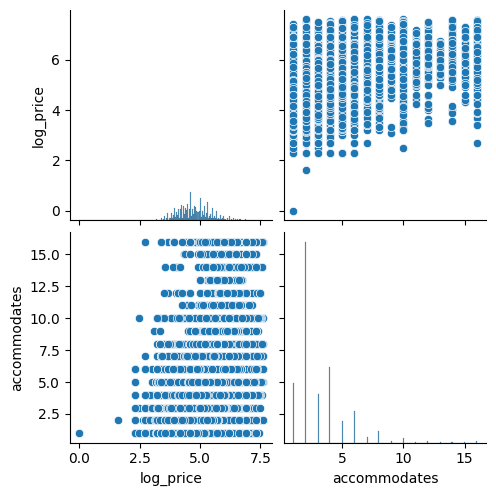

In [7]:
variables = [
    'log_price',
    'accommodates',
]

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[variables])

plt.show()

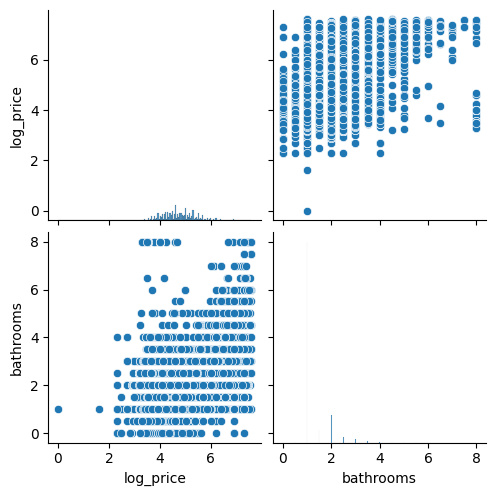

In [8]:
variables = [
    'log_price',
    'bathrooms',
]
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[variables])

plt.show()

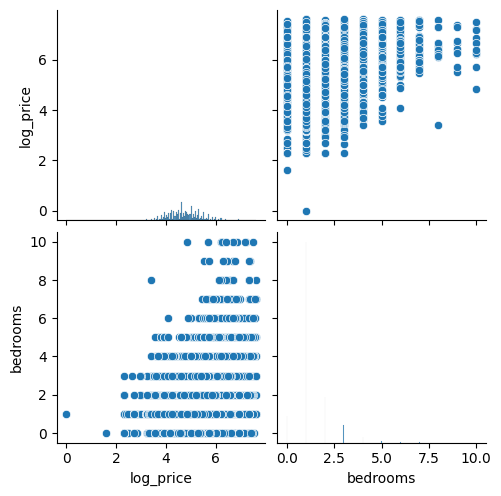

In [9]:
variables = [
    'log_price',
    'bedrooms',
]
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[variables])

plt.show()

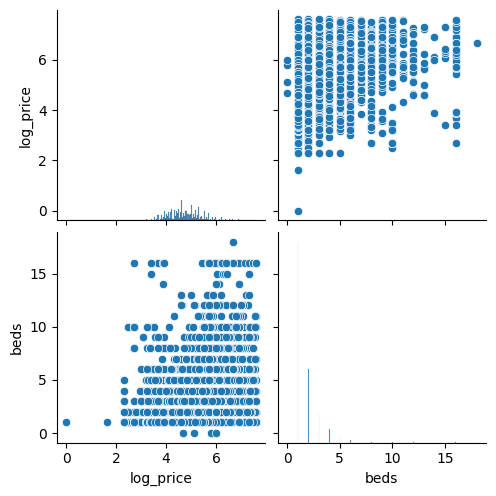

In [10]:
variables = [
    'log_price',
    'beds',
]

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[variables])

plt.show()

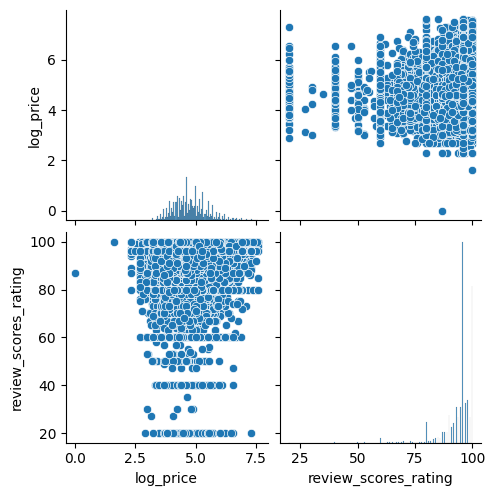

In [12]:
variables = [
    'log_price',
    'review_scores_rating',
]

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[variables])

plt.show()

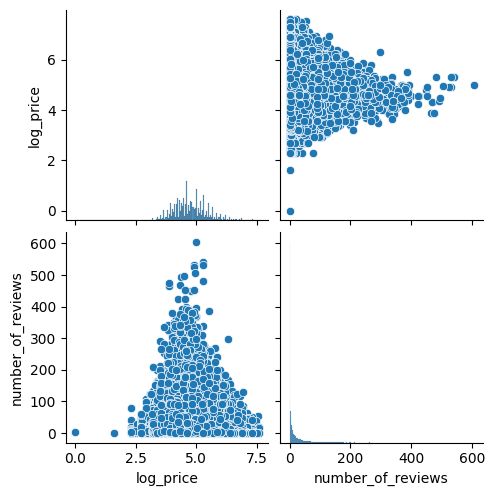

In [13]:
variables = [
    'log_price',
    'number_of_reviews'
]

import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[variables])

plt.show()

## Grupos de entrenamiento y prueba

In [14]:
from sklearn.model_selection import train_test_split

X = df[[
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'review_scores_rating',
    'number_of_reviews'
]]

y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

El conjunto de datos fue dividido en grupos de entrenamiento, se selecciono un 80% de los datospara entrenar al modelo y un 20% para evaluar su desempeño, las variables independientes utilizadas fueron las antes mencionadas que es el alojamineto, capacidad, numero habitacicones, etc. Mientras tanto, la variable dependiente fue el precio. 

## Construcción y entrenamiento del modelo:

In [15]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Para el modelo de regresión lineal múltiple se seleccionaron variables relacionadas con la capacidad, características y popularidad del alojamiento. También se consideró la posible multicolinealidad entre variables similares, como beds, bedrooms y accommodates, debido a que representan características relacionadas con el tamaño del alojamiento. Sin embargo, se decidió mantenerlas por su relevancia en la predicción del precio.

## Evaluación del modelo:

In [16]:
from sklearn.metrics import r2_score

y_pred = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.34299407962588613


Aqui podemos ver que nuestro modelo tuvo un valo de R2 de 0.34, lo que esto indica que el 34% de la variabilidad del precio puede ser explicada por las variables seleccionadas, esto no quiere decir que esta mal, esto quiere decir que tiene una capacidad predictiva moderada, pero eso si, existen otros factores importantes que no estan puestos que tambien influyen en el precio del lugar.

## Predicciones

In [17]:
# Realizar predicciones
y_pred = modelo.predict(X_test)

# Comparar valores reales vs predicciones
comparacion = pd.DataFrame({
    'Valor real': y_test,
    'Predicción': y_pred
})

print(comparacion.head(10))

       Valor real  Predicción
4079     3.806662    4.635465
33735    4.941642    4.711170
69475    4.941642    5.031411
454      4.867534    5.047997
25153    3.663562    4.638564
42304    4.836282    5.260635
22686    5.220356    5.332936
20776    5.686975    4.590351
14934    3.555348    4.476766
39634    4.234107    5.003351


Los resultados muestran que el modelo logra acercarse a varias de los valores reales, pero, tambien hay otros valores que tienen una diferencia notable, por ejemplo, en algunos registros el modelo predijo calores cercanos al real, mientras que en otros sobre paso el valor y en otras se quedo bajo, esto nos quiere decir que el modelo fue capaz de identificar ciertas tendencias, aunque hay otras que no debido a las limitaicones mencionadas anteriormente.

## Cálculo del error cuadrático medio (MSE)

In [19]:
from sklearn.metrics import mean_squared_error

# Calcular el MSE
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.3375209567901292


El modello obtuvo un MSE de aproximadamente 0.338, lo que representa el promedio del error entre las predicciones y los valores reales de la variable de precio, este resultado nos dice que el modelo tiene un nivel de error moderado y logra aproximarse de manera aceptable a los valores reales, sin embargo, simpre esta esa mejora de hacerlo mas preciso.